# Argus — CNN Training (Face Crops)

A small CNN trained directly on cropped RGB face images — no hand-engineered features at all.
Like `04_random_forest_training.ipynb` and `05_dense_nn_training.ipynb`, this is a single-image-
in, single-label-out model: one cropped face predicts one drowsiness level, no sequence, no
buffer across frames.

**Reads:** `dataset_processed/face_crops_index.csv` and the `.jpg` files it points to, written by
[`06_dataset_creation_face_crops.ipynb`](./06_dataset_creation_face_crops.ipynb) — run that first.

**Writes:** `models/cnn_face_crops_<VERSION>.keras`.

**Why "tiny" (and why a pretrained backbone variant too).** The other three model families
(LSTM, RandomForest, Dense NN) all work from a 59-dimensional-or-smaller hand-engineered feature
vector. This model instead has to learn visual features from raw pixels, which is a fundamentally
harder learning problem to solve from the amount of data this project has (tens of subjects, not
the thousands a large vision model would want) — so the from-scratch architecture below is
deliberately small and heavily regularized (few conv blocks, dropout, no pretrained backbone)
rather than a scaled-up architecture that would likely just overfit. Alongside it, this notebook
also trains and evaluates a frozen-ImageNet-MobileNetV2 variant (`build_mobilenet_backbone`,
optionally fine-tuned) side by side, specifically to test whether pretrained features generalize
across held-out subjects better than what the from-scratch model can learn from this data budget
— see the "MobileNetV2 Transfer-Learning Variant" section below. This is also the only model
family with a plausible path to running its own inference directly on cropped camera frames
without the geometric-feature pipeline at all, which is worth noting for the titulación report as
an architectural alternative, even though the project is standardizing on the LSTM for deployment
(see `03_model_training_lstm.ipynb`'s Design Decision cell) — this notebook exists to have that
comparison on record, not to replace it.


## Setup

Mounts Drive, defines the paths this notebook needs, loads `face_crops_index.csv`, and
initializes model-versioning config. Independent of any other notebook's in-memory state — only
depends on `face_crops_index.csv` and the images it references.


In [1]:
from google.colab import drive
import os
import datetime
import pandas as pd

drive.mount('/content/drive')

# --- Argus project paths (must match 06_dataset_creation_face_crops.ipynb) ---
project_folder = "/content/drive/MyDrive/Argus"
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
processed_folder = f"{dataset_folder}/dataset_processed"
face_crops_index_csv_path = os.path.join(processed_folder, "face_crops_index.csv")

if not os.path.exists(face_crops_index_csv_path):
    raise FileNotFoundError(
        f"'{face_crops_index_csv_path}' not found. Run 06_dataset_creation_face_crops.ipynb "
        "first — this notebook only reads the dataset it produces, it doesn't build it."
    )

df_face_crops = pd.read_csv(face_crops_index_csv_path)
print(f"Loaded face crop index: {len(df_face_crops)} images, "
      f"{df_face_crops['subject'].nunique()} subjects.")

# --- Model Management Configuration ---
FORCE_RETRAIN = True
VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")
# Two model paths -- this notebook now trains two 3-class variants (a from-scratch CNN and a
# MobileNetV2-backed one) side by side for comparison, not just one.
cnn_scratch_model_path = os.path.join(models_folder, f"cnn_face_crops_scratch_{VERSION_STR}.keras")
cnn_mobilenet_model_path = os.path.join(models_folder, f"cnn_face_crops_mobilenet_{VERSION_STR}.keras")

def get_latest_model(folder, prefix, extension):
    """Return the path of the most recently versioned model matching prefix/extension, or None."""
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Current version: {VERSION_STR}. Force retrain: {FORCE_RETRAIN}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded face crop index: 3751 images, 24 subjects.
✅ Model management initialized. Current version: 20260824_1725. Force retrain: True


## Splitting the Dataset

Group-aware split by subject, same rationale as every other notebook: crops from the same clip
are highly correlated (near-duplicate faces a few frames apart), so a plain random split would
leak near-duplicates across train/test and inflate reported accuracy.

Not every subject currently has all 3 classes (dataset extraction is still catching up on some
subjects — see `06_dataset_creation_face_crops.ipynb`'s per-subject completeness check). Those
subjects are **not excluded from the dataset** — they still contribute real training examples for
whichever classes they do have — but they're excluded from **test-fold eligibility**: only
subjects with all 3 classes present can be chosen as held-out test subjects. This guarantees the
test fold always has every class represented, since `StratifiedGroupKFold` can only balance
classes across whatever data actually exists — it can't invent a class a subject never recorded.

The split happens on the **index CSV** (file paths + labels), before any image is decoded — the
actual pixel loading happens lazily in the `tf.data` pipeline below.


In [2]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np


def split_by_subject_fold(df, fold_idx=0, n_splits=None, random_state=42):
    """Subject-grouped train/val/test split for face crops, parameterized by fold index so the
    same logic can drive both the main fold-0 split below AND the subject-fold cross-validation
    diagnostic further down this notebook -- without duplicating the split rules in two places.

    Only subjects with all 3 classes present are eligible to be picked as *test* subjects.
    Incomplete subjects (missing a class entirely) are NOT dropped from the dataset -- they're
    still valid training data for whichever classes they have -- they're just never candidates for
    the held-out fold, since a test fold drawn from them could be missing a class no matter how the
    split algorithm balances things (it can only work with what a subject actually recorded).
    Validation = the incomplete-subject pool, genuinely held out and structurally incapable of
    leaking into test-fold selection (it's never part of df_complete).

    Returns (df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits_used).
    """
    subject_level_sets = df.groupby('subject')['level'].agg(set)
    complete_subjects = subject_level_sets[subject_level_sets == {1, 2, 3}].index
    incomplete_subjects = subject_level_sets.index.difference(complete_subjects)

    if len(complete_subjects) < 2:
        raise ValueError(
            f"Only {len(complete_subjects)} subject(s) have all 3 classes ({list(complete_subjects)}) "
            "-- need at least 2 to hold one out for testing. Finish dataset extraction "
            "(06_dataset_creation_face_crops.ipynb) for more subjects before training."
        )

    df_complete = df[df['subject'].isin(complete_subjects)]
    n_splits = n_splits or min(5, len(complete_subjects))
    if not (0 <= fold_idx < n_splits):
        raise ValueError(f"fold_idx={fold_idx} out of range for n_splits={n_splits}")

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_iter = sgkf.split(df_complete, df_complete['level'], groups=df_complete['subject'])
    for i, (_, complete_test_pos) in enumerate(fold_iter):
        if i == fold_idx:
            break

    test_subjects = set(df_complete.iloc[complete_test_pos]['subject'])
    val_subjects = set(incomplete_subjects)

    test_mask = df['subject'].isin(test_subjects)
    val_mask = df['subject'].isin(val_subjects)
    train_mask = ~test_mask & ~val_mask

    df_train = df[train_mask].reset_index(drop=True)
    df_val = df[val_mask].reset_index(drop=True)
    df_test = df[test_mask].reset_index(drop=True)

    if len(df_val) == 0:
        raise ValueError(
            "No incomplete subjects available to build a validation set. Either every subject has "
            "all 3 classes (pick one complete subject out of the train pool manually instead) or "
            "the dataset changed shape -- don't silently fall back to validation_data=test_ds."
        )

    missing_in_test = set(df['level'].unique()) - set(df_test['level'].unique())
    if missing_in_test:
        raise ValueError(f"Test fold missing level(s) {sorted(missing_in_test)} -- treat as a bug.")

    return df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits


# Main split used by the rest of the notebook: fold 0 of the StratifiedGroupKFold, same fold the
# notebook has always used. The subject-fold cross-validation section further down reruns
# split_by_subject_fold() across the other folds to check how much this single fold's number
# varies against a different held-out subject draw.
df_train, df_val, df_test, complete_subjects, incomplete_subjects, N_SPLITS = split_by_subject_fold(
    df_face_crops, fold_idx=0
)

print(f"{len(complete_subjects)} complete subject(s) eligible for testing: {sorted(complete_subjects)}")
if len(incomplete_subjects) > 0:
    print(f"{len(incomplete_subjects)} incomplete subject(s) reserved for validation (missing a "
          f"class, so ineligible for the held-out test fold): {sorted(incomplete_subjects)}")

print(f"\nTrain: {len(df_train)} crops ({df_train['subject'].nunique()} subjects)")
print(f"Val:   {len(df_val)} crops ({df_val['subject'].nunique()} subjects, incomplete -- may not "
      f"cover all 3 classes individually, but should collectively)")
print(f"Test:  {len(df_test)} crops ({df_test['subject'].nunique()} subjects, all complete)")
print("\nPer-class support:")
print("  Train:", df_train['level'].value_counts().sort_index().to_dict())
print("  Val:  ", df_val['level'].value_counts().sort_index().to_dict())
print("  Test: ", df_test['level'].value_counts().sort_index().to_dict())

missing_in_val = set(df_face_crops['level'].unique()) - set(df_val['level'].unique())
if missing_in_val:
    print(f"⚠️  Val fold is missing level(s) {sorted(missing_in_val)} -- macro-F1 callbacks below "
          f"pass explicit labels=[0,1,2] so this doesn't silently distort the metric, but a class "
          f"with zero val examples still can't validate that class's generalization this run.")


20 complete subject(s) eligible for testing: ['subject_03', 'subject_04', 'subject_07', 'subject_08', 'subject_09', 'subject_10', 'subject_11', 'subject_12', 'subject_13', 'subject_14', 'subject_15', 'subject_16', 'subject_17', 'subject_18', 'subject_19', 'subject_20', 'subject_21', 'subject_22', 'subject_23', 'subject_24']
4 incomplete subject(s) reserved for validation (missing a class, so ineligible for the held-out test fold): ['subject_01', 'subject_02', 'subject_05', 'subject_06']

Train: 2830 crops (16 subjects)
Val:   201 crops (4 subjects, incomplete -- may not cover all 3 classes individually, but should collectively)
Test:  720 crops (4 subjects, all complete)

Per-class support:
  Train: {1: 920, 2: 960, 3: 950}
  Val:   {1: 60, 2: 91, 3: 50}
  Test:  {1: 240, 2: 240, 3: 240}


## Building the `tf.data` Pipeline

Crops are variable-size (see `06_dataset_creation_face_crops.ipynb`), so every image is resized
to a fixed `IMG_SIZE x IMG_SIZE` here. `IMG_SIZE = 96` is chosen as a small-but-workable input
resolution for a *tiny* CNN — large enough to keep eye/mouth detail legible after the face
detector's crop, small enough to keep the model and its memory footprint modest. Pixel scaling
(`1/255`) is done as a `Rescaling` layer inside the model itself (see the model definition below)
rather than as a separate `StandardScaler` artifact, so the trained `.keras` file is a fully
self-contained image-in, prediction-out artifact with no companion scaler file to keep in sync.


In [3]:
import tensorflow as tf

IMG_SIZE = 96
BATCH_SIZE = 32
CLASS_NAMES = ['Alert', 'Low Vigilant', 'Drowsy']

def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

# Augmentation beyond plain flip+brightness: the first training run reached >99% train accuracy
# within 2 epochs on a 28K-param model trained over only 4 subjects -- a strong sign it was keying
# on subject identity (skin tone, lighting, background) rather than drowsiness cues, which a
# held-out subject's face doesn't share. Small rotation/zoom/contrast jitter make that identity
# shortcut harder to exploit while staying mild enough not to distort the drowsiness-relevant
# eye/mouth region the way aggressive geometric augmentation would.
geometric_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),   # ~+/-18 degrees
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

def make_dataset(df, training: bool):
    paths = df['image_path'].to_numpy()
    labels = (df['level'].to_numpy(dtype=np.int32) - 1)  # 0-indexed: 0=Alert, 1=Low Vigilant, 2=Drowsy
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=42)
        ds = ds.map(lambda img, lbl: (tf.image.random_flip_left_right(img), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, lbl: (tf.image.random_brightness(img, max_delta=0.15), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, lbl: (geometric_augmenter(img, training=True), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(df_train, training=True)
val_ds = make_dataset(df_val, training=False)
test_ds = make_dataset(df_test, training=False)

print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}")


IMG_SIZE=96, BATCH_SIZE=32


## Tiny CNN Model Definition

Three convolutional blocks (`Conv2D -> BatchNorm -> MaxPool`), increasing filter count, followed
by `GlobalAveragePooling2D` (instead of `Flatten` + a large `Dense` layer, to keep parameter
count down and reduce overfitting risk) and a small classification head.


In [24]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout,
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
import tensorflow as tf
import keras

num_classes = len(CLASS_NAMES)

USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0
LABEL_SMOOTHING = 0.05

@keras.saving.register_keras_serializable(package="CustomLosses")
class SparseCategoricalFocalLoss(keras.losses.Loss):
    # FIX: Default reduction to 'sum_over_batch_size' instead of Reduction.AUTO to support Keras 3
    def __init__(self, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING, reduction='sum_over_batch_size', name='sparse_categorical_focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.cce_per_example = CategoricalCrossentropy(from_logits=False, reduction=None)

    def call(self, y_true, y_pred):
        y_true_int = tf.cast(y_true, tf.int32)
        num_classes_tensor = tf.shape(y_pred)[1]
        y_true_one_hot = tf.one_hot(y_true_int, depth=num_classes_tensor)

        if self.label_smoothing > 0.0:
            num_classes_float = tf.cast(num_classes_tensor, tf.float32)
            y_true_one_hot = y_true_one_hot * (1.0 - self.label_smoothing) + (self.label_smoothing / num_classes_float)

        ce = self.cce_per_example(y_true_one_hot, y_pred)
        probs_true_class = tf.reduce_sum(y_pred * y_true_one_hot, axis=-1)
        probs_true_class = tf.clip_by_value(probs_true_class, 1e-7, 1.0 - 1e-7)

        modulating_factor = tf.pow(1.0 - probs_true_class, self.gamma)
        return modulating_factor * ce

    def get_config(self):
        config = super().get_config()
        config.update({
            'gamma': self.gamma,
            'label_smoothing': self.label_smoothing,
        })
        return config

def build_loss():
    if USE_FOCAL_LOSS:
        return SparseCategoricalFocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
    return SparseCategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

def build_cnn_scratch(num_classes=num_classes):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Rescaling(1. / 255),
        Conv2D(16, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(),
        GlobalAveragePooling2D(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax'),
    ], name='cnn_scratch')
    model.compile(optimizer=Adam(learning_rate=0.001), loss=build_loss(), metrics=['accuracy'])
    return model

def build_mobilenet_backbone(alpha=0.35, trainable_backbone=False, learning_rate=0.001):
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), alpha=alpha, include_top=False, weights='imagenet')
    base.trainable = trainable_backbone
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_input(inputs)
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs, name='mobilenet_v2_backbone')
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss=build_loss(), metrics=['accuracy'])
    return model, base

## CNN Model Training

`class_weight`, computed from the training set's actual label distribution, for the same reason
as every other model here: `Drowsy` is plausibly the rarest class and the most safety-critical
one to not neglect. Combined with the `USE_FOCAL_LOSS` toggle and the strengthened `l2`/dropout
regularization from the cell above — see that cell's docstrings for why each was added.


In [5]:
model_scratch = build_cnn_scratch()
model_scratch.summary()


Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,387 (110.89 KB)

 Trainable params: 28,163 (110.01 KB)

 Non-trainable params: 224 (896.00 B)

In [6]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

class MacroF1Callback(Callback):
    """Adds `val_macro_f1` to the epoch's `logs` dict so EarlyStopping/ModelCheckpoint below can
    select on it instead of raw accuracy. Raw val_accuracy is not a safe selection metric under
    class imbalance -- it's exactly what let a model that always predicted the majority class
    look like an 84.75%-accurate model in the first run of this notebook, while missing every
    single Drowsy case (0.00 recall). Runs one extra prediction pass over the validation set per
    epoch; negligible cost at this model/dataset size.

    Passes explicit labels=[0..num_classes-1]: df_val (the incomplete-subject pool) isn't
    guaranteed to cover every class every run, and without explicit labels sklearn infers them
    from whatever's present in that epoch's val predictions -- silently changing what "macro-F1"
    means run to run instead of comparing the same fixed set of classes throughout training.
    """
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_true = np.concatenate([y.numpy() for _, y in self.val_ds])
        y_pred = np.argmax(self.model.predict(self.val_ds, verbose=0), axis=1)
        logs['val_macro_f1'] = f1_score(y_true, y_pred, average='macro',
                                         labels=list(range(num_classes)), zero_division=0)

# Class weights computed ONCE here, reused unchanged for the MobileNetV2 variant below -- the
# only thing that differs between the two training runs is architecture, not class balancing.
train_labels = (df_train['level'].to_numpy(dtype=np.int32) - 1)
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weight_dict = dict(zip(np.unique(train_labels).tolist(), weights))

# Drowsy is the safety-critical class, and had the worst recall (0.13-0.27) in the RandomForest/
# early-CNN runs that motivated this boost in the first place. In the most recent real run
# (subject-grouped split, 24 subjects, 31.53% test acc / 0.33 macro-F1) Drowsy actually ended up
# the *best*-performing class (0.42 recall, 0.60 precision) with this boost already applied --
# Alert (0.28 recall) and Low Vigilant (0.25 recall) are now the weaker classes. Left in place
# since Drowsy is still the class it's least acceptable to regress on, but worth watching: if
# Alert/Low Vigilant recall keeps trailing after the regularization/focal-loss/MobileNetV2
# changes in this notebook, that's a sign this boost is now overcorrecting rather than helping.
DROWSY_LABEL = CLASS_NAMES.index('Drowsy')  # 2
DROWSY_WEIGHT_BOOST = 2.0
weight_dict[DROWSY_LABEL] *= DROWSY_WEIGHT_BOOST
print(f"Class weights (Drowsy boosted {DROWSY_WEIGHT_BOOST}x): {weight_dict}")

# EarlyStopping and ModelCheckpoint both monitor val_macro_f1 -- they used to watch val_loss and
# val_accuracy respectively, two different "best" epochs that could (and did) diverge.
# macro_f1_cb must run first in this list so it populates logs['val_macro_f1'] before the other
# two callbacks read it within the same epoch.
#
# All three callbacks watch val_ds (the fixed incomplete-subject pool from the split cell), NOT
# test_ds. Previously validation_data=test_ds meant every training-time decision -- early
# stopping, which epoch gets checkpointed, the LR-plateau schedule -- was made by watching the
# exact same held-out subject that the eval cell reports the final test number on. There was no
# independent check at all. test_ds is now only ever touched in the evaluation cell below, after
# training is completely finished.
macro_f1_cb_scratch = MacroF1Callback(val_ds)
early_stopping_scratch = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
checkpoint_scratch = ModelCheckpoint(filepath=os.path.join(models_folder, 'best_cnn_scratch_face_crops.keras'),
                                      monitor='val_macro_f1', mode='max', save_best_only=True)
reduce_lr_scratch = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

print("🚀 Training scratch CNN...")
history_scratch = model_scratch.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[macro_f1_cb_scratch, early_stopping_scratch, checkpoint_scratch, reduce_lr_scratch],
    class_weight=weight_dict,
    verbose=1,
)

model_scratch.save(cnn_scratch_model_path)
print(f"💾 Model saved: {cnn_scratch_model_path}")


Class weights (Drowsy boosted 2.0x): {0: np.float64(1.0253623188405796), 1: np.float64(0.9826388888888888), 2: np.float64(1.9859649122807017)}
🚀 Training scratch CNN...
Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 166s 755ms/step - accuracy: 0.5170 - loss: 0.7255 - val_accuracy: 0.4527 - val_loss: 0.5821 - val_macro_f1: 0.2078 - learning_rate: 0.0010
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6799 - loss: 0.5269 - val_accuracy: 0.2488 - val_loss: 0.7443 - val_macro_f1: 0.1366 - learning_rate: 0.0010
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7664 - loss: 0.4403 - val_accuracy: 0.2935 - val_loss: 1.1112 - val_macro_f1: 0.2314 - learning_rate: 0.0010
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8230 - loss: 0.3737 - val_accuracy: 0.2040 - val_loss: 1.7363 - val_macro_f1: 0.1139 - learning_rate: 0.0010
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8512 - loss: 0.3305 - val_accuracy: 0.3682 - val_loss: 1.4309 

## CNN Model Evaluation


Loading best scratch model from /content/drive/MyDrive/Argus/models/best_cnn_scratch_face_crops.keras...

CNN Test Loss: 1.3849
CNN Test Accuracy: 0.3667
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
CNN Test Macro-F1: 0.3614

Classification Report (CNN - Best Checkpoint):
              precision    recall  f1-score   support

       Alert       0.31      0.33      0.32       240
Low Vigilant       0.39      0.27      0.32       240
      Drowsy       0.40      0.50      0.44       240

    accuracy                           0.37       720
   macro avg       0.37      0.37      0.36       720
weighted avg       0.37      0.37      0.36       720



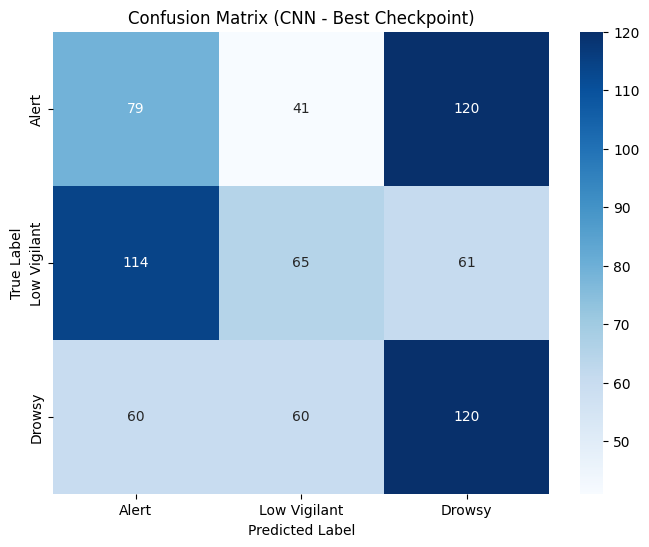

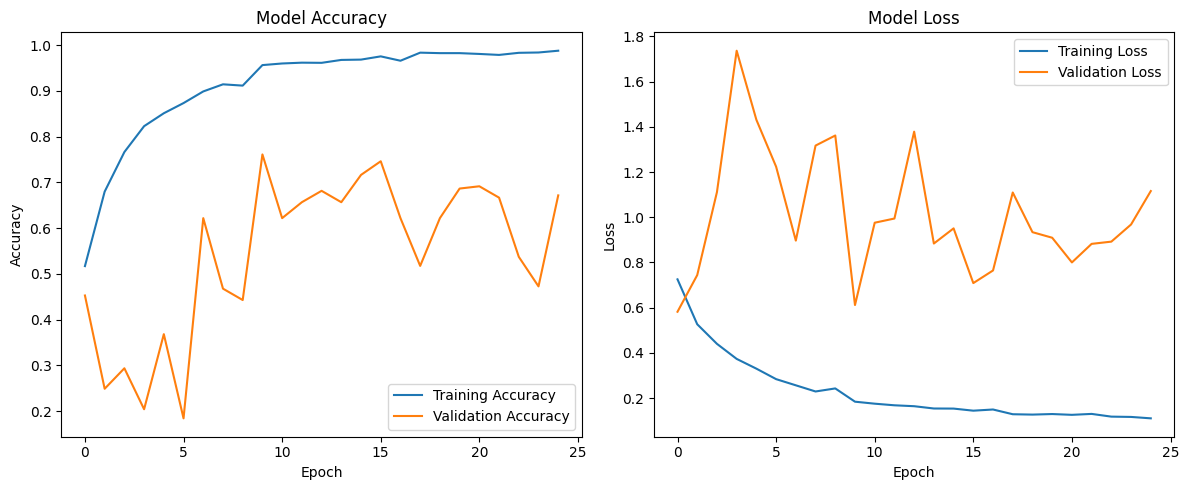

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import keras
import numpy as np

# Load the best saved checkpoint for evaluation
best_scratch_path = os.path.join(models_folder, 'best_cnn_scratch_face_crops.keras')
if os.path.exists(best_scratch_path):
    print(f"Loading best scratch model from {best_scratch_path}...")
    # WORKAROUND: The saved file might still refer to the old 'loss_fn' closure.
    # We map 'loss_fn' to our new serializable class so Keras can resolve it.
    custom_objects = {
        'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss,
        'loss_fn': SparseCategoricalFocalLoss
    }
    model_eval = tf.keras.models.load_model(best_scratch_path, custom_objects=custom_objects)
else:
    print("Best checkpoint not found, falling back to in-memory model.")
    model_eval = model_scratch

loss, accuracy = model_eval.evaluate(test_ds, verbose=0)
print(f"\nCNN Test Loss: {loss:.4f}")
print(f"CNN Test Accuracy: {accuracy:.4f}")
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = model_eval.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Macro-F1 (unweighted mean of per-class F1) alongside accuracy
print(f"CNN Test Macro-F1: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

print("\nClassification Report (CNN - Best Checkpoint):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (CNN - Best Checkpoint)')
plt.show()

# Note: Plotting history still uses the last run's training session object
if 'history_scratch' in globals():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_scratch.history['accuracy'], label='Training Accuracy')
    plt.plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_scratch.history['loss'], label='Training Loss')
    plt.plot(history_scratch.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

## MobileNetV2 Transfer-Learning Variant (Frozen Backbone → Fine-Tune)

`build_mobilenet_backbone()` was defined above but never actually trained — this section closes
that gap. Two phases, the standard transfer-learning recipe: train the new head to convergence
with the pretrained backbone completely frozen first, *then* unfreeze a small number of the
backbone's final layers and continue training at a much lower learning rate. Fine-tuning the
whole backbone from the start would destroy the pretrained ImageNet features before the new head
has learned anything useful to backpropagate through them.

Uses the exact same `train_ds`/`val_ds`/`test_ds`, `weight_dict`, and val-macro-F1-based
callback pattern as the scratch model above, so any accuracy/recall difference between the two
is attributable to architecture, not to a different training setup.


In [11]:
model_mobilenet, mobilenet_base = build_mobilenet_backbone(alpha=0.35, trainable_backbone=False)
model_mobilenet.summary()

# Same class_weight dict as the scratch model -- see the cell above for why it's computed once
# and reused. A fresh MacroF1Callback/EarlyStopping/ModelCheckpoint/ReduceLROnPlateau set is
# still needed (Keras callbacks are stateful per-model), but the *pattern* is identical.
macro_f1_cb_mobilenet = MacroF1Callback(val_ds)
early_stopping_mobilenet = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
checkpoint_mobilenet_frozen = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_mobilenet_frozen_face_crops.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
reduce_lr_mobilenet = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)

print("🚀 Training MobileNetV2 head (backbone frozen)...")
history_mobilenet_frozen = model_mobilenet.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[macro_f1_cb_mobilenet, early_stopping_mobilenet, checkpoint_mobilenet_frozen, reduce_lr_mobilenet],
    class_weight=weight_dict,
    verbose=1,
)


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


Model: "mobilenet_v2_backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,387 (1.88 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 410,208 (1.56 MB)

🚀 Training MobileNetV2 head (backbone frozen)...
Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 56s 412ms/step - accuracy: 0.6166 - loss: 0.6353 - val_accuracy: 0.3184 - val_loss: 0.8471 - val_macro_f1: 0.3378 - learning_rate: 0.0010
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8187 - loss: 0.3360 - val_accuracy: 0.3831 - val_loss: 1.0499 - val_macro_f1: 0.3762 - learning_rate: 0.0010
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8820 - loss: 0.2432 - val_accuracy: 0.4627 - val_loss: 0.8337 - val_macro_f1: 0.4631 - learning_rate: 0.0010
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9180 - loss: 0.1940 - val_accuracy: 0.4776 - val_loss: 0.9410 - val_macro_f1: 0.4785 - learning_rate: 0.0010
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9187 - loss: 0.1915 - val_accuracy: 0.4627 - val_loss: 1.0276 - val_macro_f1: 0.4614 - learning_rate: 0.0010
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9378 - l

### Fine-tuning phase

Unfreeze the last ~30 layers of the MobileNetV2 base (out of ~150 total at `alpha=0.35`) and
continue training at a much lower learning rate (`1e-5`, vs. the head phase's `1e-3`). Only the
*later* layers are unfrozen — those encode higher-level, more task-specific features; the early
layers (edges, colors, basic textures) are exactly the generic features transfer learning is
meant to keep. `base(x, training=False)` inside the model still keeps BatchNorm's running
statistics frozen throughout — unfreezing a `BatchNormalization` layer's *weights* while it keeps
computing batch statistics from this project's small batches would destabilize training,
independent of which layers are otherwise trainable.


In [20]:
# Load the best frozen-head checkpoint before fine-tuning
best_frozen_path = os.path.join(models_folder, 'best_cnn_mobilenet_frozen_face_crops.keras')

# Fix: Include custom_objects (and the loss_fn workaround) to enable loading
def focal_loss_loader(**kwargs):
    # Force a valid reduction value if 'auto' or nothing is passed
    kwargs['reduction'] = 'sum_over_batch_size'
    return SparseCategoricalFocalLoss(**kwargs)

custom_objects = {
    'SparseCategoricalFocalLoss': focal_loss_loader,
    'loss_fn': focal_loss_loader
}

print(f"Attempting to load model from {best_frozen_path}...")
model_mobilenet_ft = tf.keras.models.load_model(best_frozen_path, custom_objects=custom_objects)

base_ft = next(l for l in model_mobilenet_ft.layers if isinstance(l, tf.keras.Model))
base_ft.trainable = True
FINE_TUNE_UNFREEZE_LAYERS = 30
for layer in base_ft.layers[:-FINE_TUNE_UNFREEZE_LAYERS]:
    layer.trainable = False
for layer in base_ft.layers[-FINE_TUNE_UNFREEZE_LAYERS:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# FIX: Pass a valid reduction directly to resolve the ValueError from the class default
if USE_FOCAL_LOSS:
    ft_loss = SparseCategoricalFocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING, reduction='sum_over_batch_size')
else:
    ft_loss = SparseCategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING, reduction='sum_over_batch_size')

FINE_TUNE_LR = 1e-5
model_mobilenet_ft.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR),
                            loss=ft_loss, metrics=['accuracy'])

macro_f1_cb_ft = MacroF1Callback(val_ds)
early_stopping_ft = EarlyStopping(monitor='val_macro_f1', mode='max', patience=8, restore_best_weights=True)
checkpoint_ft = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_mobilenet_finetuned_face_crops.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)

print(f"🚀 Fine-tuning MobileNetV2 (last {FINE_TUNE_UNFREEZE_LAYERS} backbone layers, lr={FINE_TUNE_LR})...")
history_mobilenet_ft = model_mobilenet_ft.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[macro_f1_cb_ft, early_stopping_ft, checkpoint_ft, reduce_lr_ft],
    class_weight=weight_dict,
    verbose=1,
)

model_mobilenet_ft.save(cnn_mobilenet_model_path)
print(f"💾 Model saved: {cnn_mobilenet_model_path}")

Attempting to load model from /content/drive/MyDrive/Argus/models/best_cnn_mobilenet_frozen_face_crops.keras...
🚀 Fine-tuning MobileNetV2 (last 30 backbone layers, lr=1e-05)...
Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 37s 253ms/step - accuracy: 0.9618 - loss: 0.1171 - val_accuracy: 0.5124 - val_loss: 1.0138 - val_macro_f1: 0.5060 - learning_rate: 1.0000e-05
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9597 - loss: 0.1165 - val_accuracy: 0.5025 - val_loss: 1.0063 - val_macro_f1: 0.4925 - learning_rate: 1.0000e-05
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9682 - loss: 0.1088 - val_accuracy: 0.4975 - val_loss: 1.0444 - val_macro_f1: 0.4901 - learning_rate: 1.0000e-05
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9625 - loss: 0.1089 - val_accuracy: 0.5025 - val_loss: 1.0017 - val_macro_f1: 0.4968 - learning_rate: 1.0000e-05
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9703 - loss: 0.1083 - val_accuracy: 0.5075 -

### MobileNetV2 Evaluation + Scratch/Frozen/Fine-Tuned Comparison

Same evaluation shape as the scratch model's evaluation cell above, run against the fine-tuned
checkpoint. The comparison table after it is the "side by side" comparison this notebook's setup
cell has claimed to do since before either variant was actually trained.


Loading best fine-tuned MobileNetV2 model from /content/drive/MyDrive/Argus/models/best_cnn_mobilenet_finetuned_face_crops.keras...

MobileNetV2 (fine-tuned) Test Loss: 2.5171
MobileNetV2 (fine-tuned) Test Accuracy: 0.1681
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step
MobileNetV2 (fine-tuned) Test Macro-F1: 0.1447

Classification Report (MobileNetV2 - Fine-Tuned):
              precision    recall  f1-score   support

       Alert       0.19      0.27      0.22       240
Low Vigilant       0.00      0.00      0.00       240
      Drowsy       0.19      0.24      0.21       240

    accuracy                           0.17       720
   macro avg       0.13      0.17      0.14       720
weighted avg       0.13      0.17      0.14       720



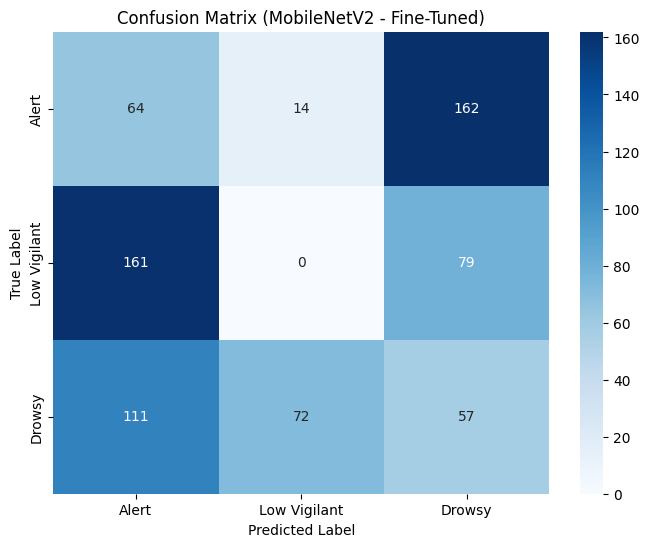

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step

=== Scratch vs. MobileNetV2 (frozen) vs. MobileNetV2 (fine-tuned), same test_ds ===
                          Test Accuracy  Macro F1  Alert Recall  \
Variant                                                           
Scratch CNN                      0.3667    0.3614        0.3292   
MobileNetV2 (frozen)             0.1681    0.1428        0.3458   
MobileNetV2 (fine-tuned)         0.1681    0.1447        0.2667   

                          Low Vigilant Recall  Drowsy Recall  
Variant                                                       
Scratch CNN                            0.2708         0.5000  
MobileNetV2 (frozen)                   0.0000         0.1583  
MobileNetV2 (fine-tuned)               0.0000         0.2375  


In [21]:
best_ft_path = os.path.join(models_folder, 'best_cnn_mobilenet_finetuned_face_crops.keras')
if os.path.exists(best_ft_path):
    print(f"Loading best fine-tuned MobileNetV2 model from {best_ft_path}...")
    model_mobilenet_eval = tf.keras.models.load_model(best_ft_path)
else:
    print("Best fine-tuned checkpoint not found, falling back to in-memory model.")
    model_mobilenet_eval = model_mobilenet_ft

loss_mobilenet, accuracy_mobilenet = model_mobilenet_eval.evaluate(test_ds, verbose=0)
print(f"\nMobileNetV2 (fine-tuned) Test Loss: {loss_mobilenet:.4f}")
print(f"MobileNetV2 (fine-tuned) Test Accuracy: {accuracy_mobilenet:.4f}")

y_pred_probs_mobilenet = model_mobilenet_eval.predict(test_ds)
y_pred_mobilenet = np.argmax(y_pred_probs_mobilenet, axis=1)
# y_true is the same test set/order as the scratch model's evaluation cell above (test_ds is
# never shuffled), so it's reused rather than recomputed.
macro_f1_mobilenet = f1_score(y_true, y_pred_mobilenet, average='macro', zero_division=0)
print(f"MobileNetV2 (fine-tuned) Test Macro-F1: {macro_f1_mobilenet:.4f}")

print("\nClassification Report (MobileNetV2 - Fine-Tuned):")
print(classification_report(y_true, y_pred_mobilenet, target_names=CLASS_NAMES, zero_division=0))

conf_matrix_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_mobilenet, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (MobileNetV2 - Fine-Tuned)')
plt.show()

# --- Comparison table: scratch vs. frozen-backbone-only vs. fine-tuned -------------------------
# Frozen-only numbers come from the phase-1 checkpoint (before fine-tuning touched any backbone
# weights), evaluated fresh here rather than trusting a training-time val metric, for the same
# reason the scratch/fine-tuned numbers above are read off test_ds and not val_ds.
model_mobilenet_frozen_eval = tf.keras.models.load_model(
    os.path.join(models_folder, 'best_cnn_mobilenet_frozen_face_crops.keras')
)
y_pred_mobilenet_frozen = np.argmax(model_mobilenet_frozen_eval.predict(test_ds), axis=1)

comparison_rows = []
for variant_name, y_pred_variant in [
    ('Scratch CNN', y_pred),
    ('MobileNetV2 (frozen)', y_pred_mobilenet_frozen),
    ('MobileNetV2 (fine-tuned)', y_pred_mobilenet),
]:
    report = classification_report(y_true, y_pred_variant, target_names=CLASS_NAMES,
                                    output_dict=True, zero_division=0)
    comparison_rows.append({
        'Variant': variant_name,
        'Test Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Alert Recall': report['Alert']['recall'],
        'Low Vigilant Recall': report['Low Vigilant']['recall'],
        'Drowsy Recall': report['Drowsy']['recall'],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Variant')
print("\n=== Scratch vs. MobileNetV2 (frozen) vs. MobileNetV2 (fine-tuned), same test_ds ===")
print(comparison_df.round(4))


## Subject-Fold Cross-Validation (Diagnostic)

The scratch-CNN result above (31.53% test accuracy / 0.33 macro-F1) comes from a **single**
`StratifiedGroupKFold` fold — 4 held-out test subjects, out of only 20 complete-class subjects
total. The training log for that run also showed a large gap between validation performance
(macro-F1 up to ~0.77 on the 4 validation subjects) and test performance, which is at least
partly a small-N symptom: with folds this small, which 4 subjects happen to land in the test
fold can swing the reported number substantially on its own, independent of any real model
quality difference.

This cell reruns `split_by_subject_fold()` across multiple folds (fresh scratch model each time,
same architecture/regularization/loss/callbacks as above) and reports **mean ± std** macro-F1 and
per-class recall across folds — the question this answers is "how much does the number move if
a different 4 subjects get held out", not "what's the best possible model". This is meant as a
**one-time reliability check, not something to rerun every session** — it trains
`N_CV_FOLDS` full models back-to-back, so treat it as expensive. `RUN_CROSS_VALIDATION` defaults
to `False` for exactly that reason; flip it on deliberately when this specific question is what
you need answered.


In [25]:
RUN_CROSS_VALIDATION = True
N_CV_FOLDS = min(3, N_SPLITS)  # capped at 3 (not the full 5) to keep this diagnostic's runtime
                                # bounded -- 3 folds is enough to see whether the spread is small
                                # or large, without training 5 full models for a one-time check.
CV_EPOCHS = 40  # shorter than the main 100-epoch budget: this is checking fold-to-fold spread,
                 # not searching for each fold's absolute best checkpoint.

if not RUN_CROSS_VALIDATION:
    print("RUN_CROSS_VALIDATION is False -- skipping. Set it to True to run this diagnostic "
          f"({N_CV_FOLDS} full training runs).")
else:
    cv_results = []
    for fold_idx in range(N_CV_FOLDS):
        print(f"\n{'=' * 60}\nFold {fold_idx + 1}/{N_CV_FOLDS}\n{'=' * 60}")
        fold_df_train, fold_df_val, fold_df_test, _, _, _ = split_by_subject_fold(
            df_face_crops, fold_idx=fold_idx, n_splits=N_SPLITS
        )
        fold_train_ds = make_dataset(fold_df_train, training=True)
        fold_val_ds = make_dataset(fold_df_val, training=False)
        fold_test_ds = make_dataset(fold_df_test, training=False)

        fold_train_labels = (fold_df_train['level'].to_numpy(dtype=np.int32) - 1)
        fold_weights = compute_class_weight('balanced', classes=np.unique(fold_train_labels),
                                             y=fold_train_labels)
        fold_weight_dict = dict(zip(np.unique(fold_train_labels).tolist(), fold_weights))
        fold_weight_dict[DROWSY_LABEL] *= DROWSY_WEIGHT_BOOST

        fold_model = build_cnn_scratch()
        fold_macro_f1_cb = MacroF1Callback(fold_val_ds)
        fold_early_stopping = EarlyStopping(monitor='val_macro_f1', mode='max', patience=10,
                                             restore_best_weights=True)
        fold_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

        fold_model.fit(
            fold_train_ds, epochs=CV_EPOCHS, validation_data=fold_val_ds,
            callbacks=[fold_macro_f1_cb, fold_early_stopping, fold_reduce_lr],
            class_weight=fold_weight_dict, verbose=0,
        )

        fold_y_true = np.concatenate([y.numpy() for _, y in fold_test_ds])
        fold_y_pred = np.argmax(fold_model.predict(fold_test_ds, verbose=0), axis=1)
        fold_report = classification_report(fold_y_true, fold_y_pred, target_names=CLASS_NAMES,
                                             output_dict=True, zero_division=0)
        cv_results.append({
            'fold': fold_idx,
            'test_accuracy': fold_report['accuracy'],
            'macro_f1': fold_report['macro avg']['f1-score'],
            'alert_recall': fold_report['Alert']['recall'],
            'low_vigilant_recall': fold_report['Low Vigilant']['recall'],
            'drowsy_recall': fold_report['Drowsy']['recall'],
        })
        print(f"Fold {fold_idx}: acc={fold_report['accuracy']:.4f}, "
              f"macro_f1={fold_report['macro avg']['f1-score']:.4f}")

    cv_df = pd.DataFrame(cv_results).set_index('fold')
    print(f"\n=== Cross-validation results ({N_CV_FOLDS} folds) ===")
    print(cv_df.round(4))
    print("\nMean ± std across folds:")
    print(cv_df.agg(['mean', 'std']).round(4))



Fold 1/3
Fold 0: acc=0.4111, macro_f1=0.4059

Fold 2/3
Fold 1: acc=0.4123, macro_f1=0.4038

Fold 3/3
Fold 2: acc=0.2545, macro_f1=0.2169

=== Cross-validation results (3 folds) ===
      test_accuracy  macro_f1  alert_recall  low_vigilant_recall  \
fold                                                               
0            0.4111    0.4059        0.5125               0.2542   
1            0.4123    0.4038        0.4458               0.5583   
2            0.2545    0.2169        0.6000               0.0333   

      drowsy_recall  
fold                 
0            0.4667  
1            0.2400  
2            0.1818  

Mean ± std across folds:
      test_accuracy  macro_f1  alert_recall  low_vigilant_recall  \
mean         0.3593    0.3422        0.5194               0.2819   
std          0.0907    0.1085        0.0773               0.2636   

      drowsy_recall  
mean         0.2962  
std          0.1505  


## The single biggest lever left: more subjects

Every change in this notebook (regularization, focal loss, a pretrained backbone, cross-
validation to measure reliability) works within a 20-complete-subject budget. That's still small
for a deep model learning from raw pixels — per-subject visual identity (skin tone, lighting,
background, camera angle) is a shortcut this small a model+dataset combination can exploit no
matter how much the architecture/loss side is tuned, and only more *subjects* (not more frames
from the same subjects — `sampling_fps=1` in `06_dataset_creation_face_crops.ipynb` already
made that call deliberately) directly shrinks how exploitable that shortcut is.

UTA-RLDD provides up to 60 subjects; this dataset currently has 24 extracted subjects, 20 of them
complete-class. Concretely, before the next `06`/`07` rerun: in Colab, check
`face_crops_index.csv` (or `06`'s own per-subject completeness check) against how many
`subject_NN` folders exist under `dataset/raw_videos/` on Drive, and extend
`scripts/extract_uta_rldd_clips.py`'s `--start-subject` range to cover whichever UTA-RLDD
subjects haven't been extracted yet — that folder listing lives on Drive, not in this repo, so
it isn't something to check from here.


### Reading this result alongside the other models

This model has strictly less information available per prediction than the geometric-feature
models — it never sees EAR/MAR/blendshapes/pose directly, only pixels, and has to (re-)learn
whatever of that signal it can from a comparatively small image dataset. Treat any accuracy gap
against RandomForest/Dense NN as evidence about how hard that visual-feature-learning problem is
from this dataset's size, not as a verdict on face-crop CNNs as an approach in general.

Unlike when this note was first written, this notebook now actually includes a pretrained-
backbone comparison (the MobileNetV2 section above) rather than treating it as a hypothetical
that "this project's data budget currently doesn't support" — go read that section's comparison
table for whether it closed any of the gap in practice. If it didn't move the needle much, that's
itself informative: it would suggest the ceiling here is less about backbone capacity/features
and more about subject count (see "The single biggest lever left" above) or about how much
drowsiness signal a single frame can carry at all, independent of architecture — the same
single-instant-in-time limitation the root `CLAUDE.md`'s RandomForest/Dense NN findings already
point at.
